## How this data was generated

```bash
cd camonitor-cliff/
python3 run_channel_cost_test.py --scenarios B,D --out-dir ../docs/camonitor-cliff/channel_cost_bd
```

Defaults used: `--n-servers 10 --pvs-per-server 500 --pvs-per-buffer 20 --round-interval-s 0.3`
(10 servers × 500 PVs = 5,000 channels per scenario) — same scale as the B-vs-C run in
`../channel_cost/results.ipynb`, for direct comparability.

# Channel cost — B vs D (does leaving the monitor on help?)

Loads the CSVs written by `run_channel_cost_test.py --scenarios B,D` (in `camonitor-cliff/`) and
compares Scenario B against a new Scenario D at real scale (5,000 channels, spread across 10 mock
IOCs — see that script's module docstring for why one server alone can't be pushed this far).

- **B** — `epics.PV(pvname, auto_monitor=False)`, channel left open (never cleared).
- **D** — plain `epics.caget(pvname)` (pyepics' default monitor stays subscribed), but the scan's
  own channels are cleared right after via the same scoped logic as
  `slac_timing.buffer.Buffer._clear_ca_cache()` (find every cached PV object / channel whose name
  ends in this buffer's `HST{n}` suffix, `disconnect()` + `clear_channel()` it).

B never enables a monitor and never clears anything; D does the opposite on both counts. The
question this notebook answers: does leaving the monitor on buy back any *performance* advantage
(faster reads because a value may already be pushed) that would offset the cost of re-establishing
a subscription every time the cache is cleared — not just how each compares on memory.

See `../channel_cost/results.ipynb` for the earlier B-vs-C memory-only comparison (C is B plus an
explicit `clear_channel()` every round, monitor never enabled either) and
`../../../camonitor-cliff/README.md` for the full write-up.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

HERE = Path.cwd()
COLORS = {"B": "tab:orange", "D": "tab:purple"}
LABELS = {
    "B": "B — auto_monitor=False, never cleared",
    "D": "D — caget() default (monitor on) + periodic scoped clear",
}

In [2]:
mem = {
    label: pd.read_csv(HERE / f"results_{label}.csv")
    for label in ["B", "D"]
}
rounds = {
    label: pd.read_csv(HERE / f"round_times_{label}.csv")
    for label in ["B", "D"]
}
for label in ["B", "D"]:
    m, r = mem[label], rounds[label]
    print(label, "mem", m.shape, f"{m['elapsed_s'].iloc[0]:.1f}s -> {m['elapsed_s'].iloc[-1]:.1f}s",
          "| rounds", r.shape)

B mem (757, 3) 0.0s -> 757.0s | rounds (260, 3)
D mem (995, 3) 0.0s -> 995.0s | rounds (260, 3)


## Memory

In [3]:
def summarize_memory(label, df):
    # Settled baseline: server RSS jumps during the first ~1-2s of
    # asyncio/scan-callback warm-up, independent of any client channels.
    # Real plateau: the elapsed_s where channels_touched_so_far first
    # reaches its max (all channels touched), not assumed from configured
    # round timing (per-round time grows substantially with total channel
    # count already open at this scale).
    baseline = df[df["elapsed_s"] >= 2.0].iloc[0]
    total_channels = df["channels_touched_so_far"].max()
    plateau = df[df["channels_touched_so_far"] == total_channels].iloc[0]
    final = df.iloc[-1]
    delta = plateau["server_mem_rss_mb"] - baseline["server_mem_rss_mb"]
    per_channel_kb = (delta / total_channels) * 1024 if total_channels else 0
    return {
        "scenario": LABELS[label],
        "total_channels": int(total_channels),
        "baseline_rss_mb": round(baseline["server_mem_rss_mb"], 1),
        "plateau_t_s": round(plateau["elapsed_s"], 1),
        "plateau_rss_mb": round(plateau["server_mem_rss_mb"], 1),
        "delta_mb": round(delta, 2),
        "kb_per_channel": round(per_channel_kb, 2),
    }

memory_summary = pd.DataFrame([summarize_memory(label, df) for label, df in mem.items()]).set_index("scenario")
memory_summary

,total_channels,baseline_rss_mb,plateau_t_s,plateau_rss_mb,delta_mb,kb_per_channel
scenario,,,,,,
"B — auto_monitor=False, never cleared",5000,1133.5,747.0,1157.3,23.77,4.87
D — caget() default (monitor on) + periodic scoped clear,5000,1136.1,955.9,1236.0,99.97,20.47


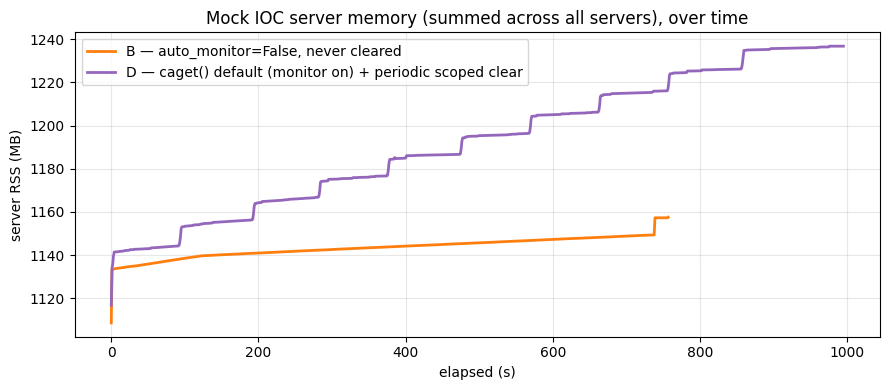

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, df in mem.items():
    ax.plot(df["elapsed_s"], df["server_mem_rss_mb"], label=LABELS[label], color=COLORS[label], lw=2)
ax.set_xlabel("elapsed (s)")
ax.set_ylabel("server RSS (MB)")
ax.set_title("Mock IOC server memory (summed across all servers), over time")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

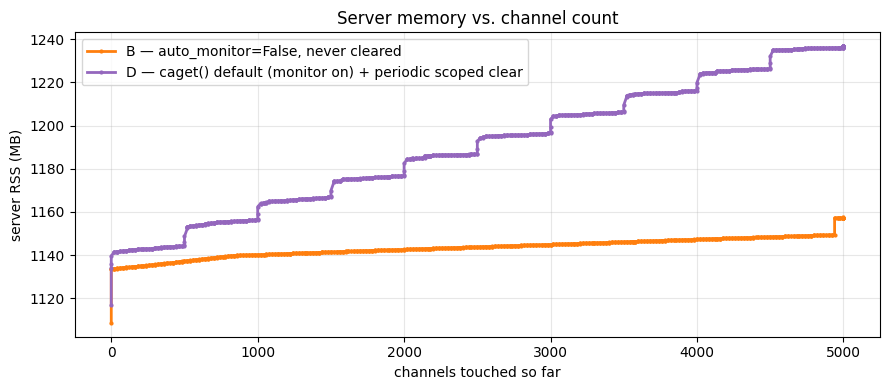

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, df in mem.items():
    ax.plot(df["channels_touched_so_far"], df["server_mem_rss_mb"], label=LABELS[label], color=COLORS[label], lw=2, marker="o", ms=2)
ax.set_xlabel("channels touched so far")
ax.set_ylabel("server RSS (MB)")
ax.set_title("Server memory vs. channel count")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

## Round duration (performance)

In [6]:
def summarize_rounds(label, df):
    d = df["round_dur_s"].dropna()
    first10 = d.iloc[:10].mean()
    last10 = d.iloc[-10:].mean()
    trend = "growing" if last10 > first10 * 1.1 else "shrinking" if last10 < first10 * 0.9 else "flat"
    return {
        "scenario": LABELS[label],
        "n_rounds": len(d),
        "mean_s": round(d.mean(), 3),
        "median_s": round(d.median(), 3),
        "p95_s": round(d.quantile(0.95), 3),
        "first10_avg_s": round(first10, 3),
        "last10_avg_s": round(last10, 3),
        "trend": trend,
    }

round_summary = pd.DataFrame([summarize_rounds(label, df) for label, df in rounds.items()]).set_index("scenario")
round_summary

,n_rounds,mean_s,median_s,p95_s,first10_avg_s,last10_avg_s,trend
scenario,,,,,,,
"B — auto_monitor=False, never cleared",260,2.610,2.696,2.909,2.578,0.698,shrinking
D — caget() default (monitor on) + periodic scoped clear,260,3.527,3.496,3.988,3.272,3.669,growing


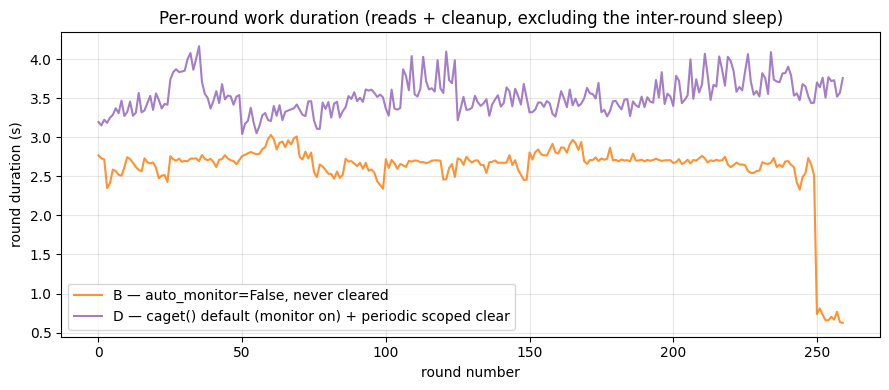

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, df in rounds.items():
    ax.plot(df["round_num"], df["round_dur_s"], label=LABELS[label], color=COLORS[label], lw=1.5, alpha=0.85)
ax.set_xlabel("round number")
ax.set_ylabel("round duration (s)")
ax.set_title("Per-round work duration (reads + cleanup, excluding the inter-round sleep)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

## Reading the result

- **Memory** table/plots above answer whether D's periodic scoped clearing keeps server RSS as low
  as (or lower/higher than) B's never-clear approach.
- **Round duration** table/plot answer the performance question directly: if D's `mean_s`/`median_s`
  is lower than B's, leaving the monitor on and clearing periodically is a net win on speed too, not
  just (possibly) on memory. If D's is higher, the cost of re-establishing a subscription on every
  clear outweighs whatever push-latency benefit an active monitor might otherwise offer, and B (or
  C, from the earlier notebook) remains the better choice on both axes.